# (Homework) Week 7 - DataScience Bootcamp Fall 2025

All solution cells are replaced with `# TODO` placeholders so you can fill them in.

**Name:** Sankirth Kalahasti \
**Email:** sk11617@nyu.edu

---

## Problem A: Bayesian Dice Game (Posterior Inference)

You are playing a dice game at a carnival. The operator has **three dice**, each with different biases for rolling a six:

| Die | P(6) | P(1–5) |
|-----|------|--------|
| A   | 0.10 | 0.90   |
| B   | 0.30 | 0.70   |
| C   | 0.60 | 0.40   |

Before each round, the operator secretly picks one die at random (each equally likely). He then rolls it **10 times** and tells you how many sixes appeared.

Your job is to infer which die was used using **Bayes’ Theorem**:

$$ P(Die|k) = \frac{P(k|Die)P(Die)}{\sum_{d} P(k|d)P(d)} $$

where $P(k|Die)$ follows a Binomial (n=10, p_i) distribution.

**Tasks:**
1. Simulate the experiment by picking a random die and rolling it 10 times.
2. Compute posterior probabilities for each die given observed sixes.
3. Plot likelihoods and posterior probabilities.
4. Evaluate inference accuracy over 100 rounds.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Set seed for reproducibility
np.random.seed(42)

--- Single Round Result ---
True Die: B
Observed: 5 sixes out of 10
Posterior P(A|k=5): 0.0049
Posterior P(B|k=5): 0.3374
Posterior P(C|k=5): 0.6578


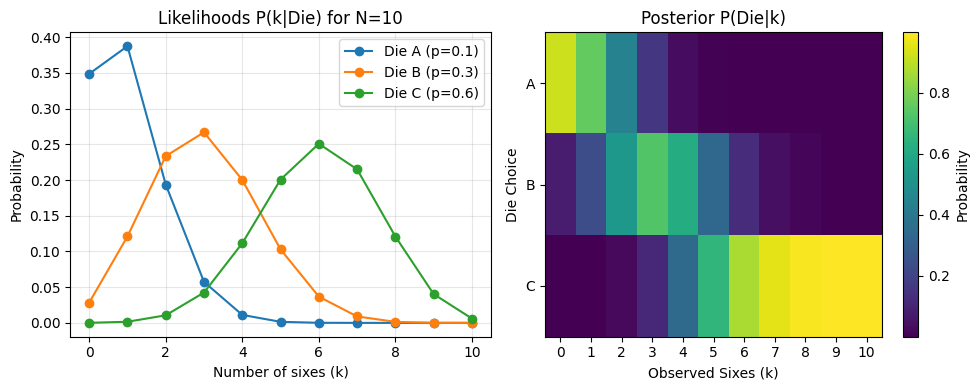


Model Accuracy over 1000 rounds: 76.00%


In [2]:
# --- Configuration ---
DICE_CONFIG = {'A': 0.1, 'B': 0.3, 'C': 0.6}
PRIORS = np.array([1/3, 1/3, 1/3])
N_ROLLS = 10

def binomial_prob(n, k, p):
    """Computes PMF of Binomial distribution."""
    return math.comb(n, k) * (p ** k) * ((1 - p) ** (n - k))

def simulate_round(dice_probs, prior, n_rolls):
    """
    Selects a die based on prior and simulates n_rolls.
    Returns: (name of true die, number of sixes observed)
    """
    dice_names = list(dice_probs.keys())

    # 1. Choose a die
    chosen_idx = np.random.choice(len(dice_names), p=prior)
    true_die = dice_names[chosen_idx]

    # 2. Roll it n times
    p_six = dice_probs[true_die]
    k_observed = np.random.binomial(n_rolls, p_six)

    return true_die, k_observed

def compute_posterior(k, n_rolls, dice_probs, prior):
    """
    Computes P(Die | k) using Bayes' Theorem.
    """
    dice_names = list(dice_probs.keys())

    # Calculate Likelihood P(k | Die) for each die
    likelihoods = np.array([
        binomial_prob(n_rolls, k, dice_probs[d])
        for d in dice_names
    ])

    # Bayes Numerator: P(k | Die) * P(Die)
    unnormalized_posterior = likelihoods * prior

    # Bayes Denominator: P(k) (Sum of numerators)
    evidence = unnormalized_posterior.sum()

    return unnormalized_posterior / evidence

# --- Execution & Visualization ---

# 1. Single Round Example
true_die, k = simulate_round(DICE_CONFIG, PRIORS, N_ROLLS)
posterior = compute_posterior(k, N_ROLLS, DICE_CONFIG, PRIORS)

print(f"--- Single Round Result ---")
print(f"True Die: {true_die}")
print(f"Observed: {k} sixes out of {N_ROLLS}")
for die, p in zip(DICE_CONFIG.keys(), posterior):
    print(f"Posterior P({die}|k={k}): {p:.4f}")

# 2. Likelihood Plot
ks = np.arange(N_ROLLS + 1)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
for die, p in DICE_CONFIG.items():
    likelihood_vals = [binomial_prob(N_ROLLS, k_val, p) for k_val in ks]
    plt.plot(ks, likelihood_vals, marker='o', label=f"Die {die} (p={p})")
plt.title(f'Likelihoods P(k|Die) for N={N_ROLLS}')
plt.xlabel('Number of sixes (k)')
plt.ylabel('Probability')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Posterior Heatmap
posterior_matrix = np.array([
    compute_posterior(k_val, N_ROLLS, DICE_CONFIG, PRIORS)
    for k_val in ks
])

plt.subplot(1, 2, 2)
plt.imshow(posterior_matrix.T, cmap='viridis', aspect='auto')
plt.yticks(range(3), list(DICE_CONFIG.keys()))
plt.xticks(ks)
plt.xlabel('Observed Sixes (k)')
plt.ylabel('Die Choice')
plt.title('Posterior P(Die|k)')
plt.colorbar(label='Probability')

plt.tight_layout()
plt.show()

# 4. Accuracy Evaluation
num_trials = 1000  # Increased trials for better statistical significance
correct_preds = 0
dice_names = list(DICE_CONFIG.keys())

for _ in range(num_trials):
    t_die, k_obs = simulate_round(DICE_CONFIG, PRIORS, N_ROLLS)
    post = compute_posterior(k_obs, N_ROLLS, DICE_CONFIG, PRIORS)

    # Prediction is the die with max posterior probability (MAP estimate)
    predicted_die = dice_names[np.argmax(post)]

    if predicted_die == t_die:
        correct_preds += 1

print(f"\nModel Accuracy over {num_trials} rounds: {correct_preds/num_trials:.2%}")

## Problem B: Linear Regression
Given x=[-2,-1,0,1,2] and y=[7,4,3,4,7]. Fit a linear model using the normal equation.

In [3]:
# Data
x = np.array([-2, -1, 0, 1, 2])
y = np.array([7, 4, 3, 4, 7])

# Add bias term (column of ones) to X
# Shape becomes (5, 2)
X_b = np.c_[np.ones(len(x)), x]

# Normal Equation: theta = (X^T * X)^-1 * X^T * y
# Using pinv is generally safer than inv for singular matrices,
# but inv is fine for this specific homework.
theta = np.linalg.inv(X_b.T @ X_b) @ (X_b.T @ y)

# Prediction
y_pred = X_b @ theta

# Metrics
mse = np.mean((y - y_pred) ** 2)

print(f"Equation: y = {theta[0]:.2f} + {theta[1]:.2f}x")
print(f"Calculated Theta: {theta}")
print(f"MSE: {mse:.2f}")

Equation: y = 5.00 + 0.00x
Calculated Theta: [5. 0.]
MSE: 2.80


## Problem C: Gradient Descent
Minimize f(w)=5(w−11)^4. Perform steps with α=1/400 and α=1/4000000. (Print the first 5 steps and visualize)

--- Alpha = 0.0025 ---
Step 0: w = 13.0000, Cost = 80.0000
Step 1: w = 12.6000, Cost = 32.7680
Step 2: w = 12.3952, Cost = 18.9459
Step 3: w = 12.2594, Cost = 12.5786
Step 4: w = 12.1595, Cost = 9.0385

--- Alpha = 2.5e-07 ---
Step 0: w = 13.0000, Cost = 80.0000
Step 1: w = 13.0000, Cost = 79.9936
Step 2: w = 12.9999, Cost = 79.9872
Step 3: w = 12.9999, Cost = 79.9808
Step 4: w = 12.9998, Cost = 79.9744


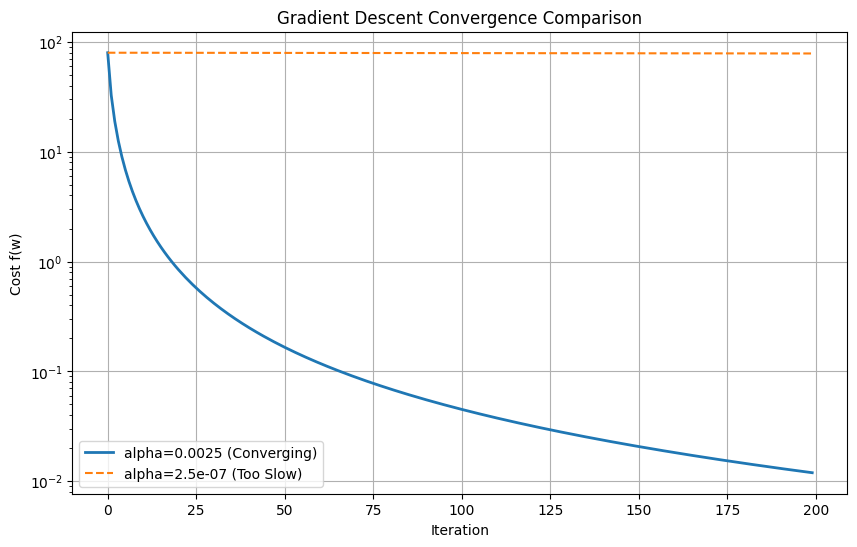

In [4]:
# 1. Define the Objective Function and Gradient
def func(w):
    return 5 * (w - 11) ** 4

def grad_func(w):
    return 20 * (w - 11) ** 3

# 2. Generic Gradient Descent Solver
def gradient_descent(start_w, learning_rate, n_steps, f, f_prime):
    w = start_w
    history = [] # Stores (w, f(w))

    for _ in range(n_steps):
        history.append((w, f(w)))
        gradient = f_prime(w)
        w = w - learning_rate * gradient

    return np.array(history)

# 3. Run Optimization
w_start = 13
steps = 200

# Scenario 1: Learning rate 1/400 (0.0025)
alpha_1 = 1/400
hist_1 = gradient_descent(w_start, alpha_1, steps, func, grad_func)

# Scenario 2: Learning rate 1/4,000,000 (Very small)
alpha_2 = 1/4000000
hist_2 = gradient_descent(w_start, alpha_2, steps, func, grad_func)

# 4. Reporting
print(f"--- Alpha = {alpha_1} ---")
for i in range(5):
    print(f"Step {i}: w = {hist_1[i, 0]:.4f}, Cost = {hist_1[i, 1]:.4f}")

print(f"\n--- Alpha = {alpha_2} ---")
for i in range(5):
    print(f"Step {i}: w = {hist_2[i, 0]:.4f}, Cost = {hist_2[i, 1]:.4f}")

# 5. Visualization
plt.figure(figsize=(10, 6))

# Plot cost history
plt.plot(hist_1[:, 1], label=f'alpha={alpha_1} (Converging)', linewidth=2)
plt.plot(hist_2[:, 1], label=f'alpha={alpha_2} (Too Slow)', linestyle='--')

plt.xlabel('Iteration')
plt.ylabel('Cost f(w)')
plt.title('Gradient Descent Convergence Comparison')
plt.legend()
plt.grid(True)
plt.yscale('log') # Log scale helps visualize the differences better
plt.show()

ALL THE BEST!